In [ ]:
import os, sys
# os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false" # Disable jax preallocation for memory debugging only
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import numpy as np
import xarray as xr
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from gofish import imagecube
from ruamel.yaml import YAML

sys.path.insert(0, '../')
import visualization, sensor, grid, line_rte, parametric_disk
from network import shard
from consts import *
import emcee
from functools import partial
import time
import visibilities_utils as vis_utils

def print_array_size_GB(array):
    num_bytes = array.size * array.dtype.itemsize
    print(f"{num_bytes / (1024**3):.4f} GB")
    
def pad_image_cube(cube, target_size=2048):
    nchan, npix, _ = cube.shape
    if npix > target_size:
        raise ValueError("Cube's dimensions are larger than target size; consider cropping instead.")
    
    pad_total = target_size - npix
    pad_before = pad_total // 2
    pad_after = pad_total - pad_before

    padded_cube = jnp.pad(cube, 
                          pad_width=((0, 0), (pad_before, pad_after), (pad_before, pad_after)),
                          mode='constant',
                          constant_values=0)
    return padded_cube

def render_cube_pinhole(ray_coords, pixel_area, disk_params, nd_co, temperature, velocity_az, bbox, freqs, nu0, obs_dir, molecular_table):
    ray_coords_sph = grid.cartesian_to_spherical(ray_coords)
    ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

    # Interpolate dataset along the ray coordinates
    gas_nd = grid.interpolate_scalar(nd_co, ray_coords_polar, bbox)
    gas_t  = grid.interpolate_scalar(temperature, ray_coords_polar, bbox, cval=1e-10)
    gas_v_az = grid.interpolate_scalar(velocity_az, ray_coords_polar, bbox)
    gas_v = parametric_disk.azimuthal_velocity(ray_coords, gas_v_az)

    # Load molecular data from disk_params
    energy_levels, radiative_transitions = line_rte.load_molecular_tables(path=molecular_table)
    _, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
        energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    n_up, n_dn = line_rte.n_up_down(
        gas_nd, gas_t, energy_levels, radiative_transitions, transition=disk_params['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params['v_turb'], gas_t)

    print(f'computing pinhole spectral cube for a total of {freqs.size} frequencies')
    images = line_rte.compute_spectral_cube_pmap(
        shard(freqs), gas_v, alpha_tot, n_up, n_dn,
        a_ud, b_ud, b_du, ray_coords, obs_dir, nu0, pixel_area
    )
    images = np.nan_to_num(images).reshape(freqs.size, *ray_coords.shape[:2])
    return images

In [ ]:
!nvidia-smi

# Grid MAPS visibilities
## Re-use some params from CLEAN FITS file

In [4]:
fov_as = 12.0
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
data_cube = imagecube(data_path, FOV=fov_as)
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
npix = data_cube.nxpix
beams_per_pix = data_cube.beams_per_pix

data_xr = xr.open_dataset('/scratch/ondemand28/len/data/radjax/HD_163296_CO_220GHz_XARRAY.nc')
uu = data_xr['uu'].to_numpy() # Lambda
vv = data_xr['vv'].to_numpy() # Lambda
data_re = data_xr['data_re'].to_numpy()
data_im = data_xr['data_im'].to_numpy()
weights = data_xr['weights'].to_numpy()
sigma = 1/np.sqrt(weights)
freqs = data_xr['freqs'].to_numpy()

nu0 = 230521497431.8133 # From MS['REF_FREQUENCY']
freqs_centered = freqs + (nu0 - freqs.mean())

# Show the array info
print(data_xr)

<xarray.Dataset> Size: 4GB
Dimensions:  (baseline: 374760, channel: 315)
Dimensions without coordinates: baseline, channel
Data variables:
    weights  (baseline) float64 3MB 2.018 1.832 1.75 ... 0.3169 0.3333 0.3476
    uu       (channel, baseline) float64 944MB -3.109e+04 ... 1.221e+05
    vv       (channel, baseline) float64 944MB 3.896e+04 ... -2.779e+05
    data_re  (channel, baseline) float64 944MB 0.317 1.156 ... 1.326 3.057
    data_im  (channel, baseline) float64 944MB -0.3264 -0.2049 ... 0.9874 0.8639
    freqs    (channel) float64 3kB 2.305e+11 2.305e+11 ... 2.305e+11 2.305e+11


## Define frequency range for ray-tracing

In [5]:
# Signal starts add [55,-55]
# More apparent [100,-100]
start_index = 100
end_index = len(freqs_centered) - start_index - 1

num_freqs = 20
freqs_selected_idx = np.round(np.linspace(start_index,end_index,num_freqs)).astype(int)
freqs_selected = freqs_centered[freqs_selected_idx]
print(freqs_selected_idx)
print(freqs_selected)

[100 106 112 118 124 130 136 142 148 154 160 166 172 178 184 190 196 202
 208 214]
[2.30525881e+11 2.30525419e+11 2.30524958e+11 2.30524497e+11
 2.30524035e+11 2.30523574e+11 2.30523112e+11 2.30522651e+11
 2.30522190e+11 2.30521728e+11 2.30521267e+11 2.30520805e+11
 2.30520344e+11 2.30519883e+11 2.30519421e+11 2.30518960e+11
 2.30518498e+11 2.30518037e+11 2.30517576e+11 2.30517114e+11]


## Grid MAPS visibilities into cube

In [6]:
from importlib import reload
reload(vis_utils)
weights_broadcasted = np.tile(weights, (uu.shape[0], 1))

scale_factor = 1
cell_size = 0.02 * scale_factor  # [arcsec]
npix = 2048 // scale_factor 
vis_npix = npix
nchan, nvis = uu.shape
# weight = jnp.ones((nchan, nvis))

weighting_type = "uniform"
append_hermitian = True

# Time this step
import time
start = time.time()

vis_grid_cuda, vis_mask_cuda, vis_cell_weight_cuda, vis_density_weight_cuda, vis_sigma_binned_cuda = vis_utils.grid_visibilities(
    uu[freqs_selected_idx], vv[freqs_selected_idx],
    data_re[freqs_selected_idx], data_im[freqs_selected_idx],
    weights_broadcasted[freqs_selected_idx], 
    cell_size, npix, weighting=weighting_type,
    append_hermitian=append_hermitian
)


nonzero_mask = jnp.abs(vis_grid_cuda) > 0

# Get indices of nonzero pixels.
vis_nonzero_indices = jnp.nonzero(nonzero_mask)

# Move to RAM instead of holding VRAM
vis_grid, vis_mask, vis_cell_weight, vis_density_weight, vis_sigma_binned = jax.device_get(vis_grid_cuda), jax.device_get(vis_mask_cuda), jax.device_get(vis_cell_weight_cuda), jax.device_get(vis_density_weight_cuda), jax.device_get(vis_sigma_binned_cuda)
vis_weight = weights_broadcasted[freqs_selected_idx]

print(f"Time taken to generate vis grid: {time.time() - start:.2f} s")

start = time.time()

MAPS_dirty_img = vis_utils.dirty_image_cube(vis_grid, weights_broadcasted[freqs_selected_idx], vis_density_weight, npix, append_hermitian)

print(f"Time taken to generate dirty image: {time.time() - start:.2f} s")

import gc

# Delete GPU-resident variables
del vis_grid_cuda
del vis_mask_cuda
del vis_cell_weight_cuda
del vis_density_weight_cuda
del vis_sigma_binned_cuda
gc.collect()


2025-04-29 03:32:21.659240: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.4 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Time taken to generate vis grid: 6.89 s
Time taken to generate dirty image: 1.38 s


0

# Grid search for CO abundance

In [6]:
import parametric_disk 
import jax.scipy as jsp
import inference
from importlib import reload
reload(inference)

disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4, # For every H how much is CO
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

param_index_dict = inference.DISK_PARAM_INDEX

posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.5, 0.0],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [1.75, 2.50],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.0, 1.0],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [40.0, 150.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [5.0, 40.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [1.0, 20.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [15.0, 115.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-1.0, 0.0],
    }
}

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs_selected
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / data_cube.nxpix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

# bounding box for interpolation
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=ray_coords_polar,
    obs_dir=obs_dir_pinhole,
    beam=None, # No beam for visibilities MCMC
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=vis_sigma_binned,
    disk_params=disk_params,
    posterior_params=posterior_params,
    nu0=nu0
)

abundance_factors = np.linspace(0.0001,0.01,10)
# abundance_factors = [1.0]
logpdf_list = []
grid_search_images = []

t_atms = np.linspace(40,150,70)

for abundance_factor in abundance_factors:
    disk_params_grid_search = parametric_disk.create_disk_params(
        q=-0.27,
        q_in=-0.57,
        r_break=70,
        log_r_c=2.3,
        v_turb=0.06,
        T_atm1=87.0,
        gamma=1.0,
        T_mid1=17.8,
        M_star=2.3 * M_sun,
        r_in=11.0,
        M_gas=0.09 * M_sun,
        co_abundance=abundance_factor*1e-4, # For every H how much is CO
        N_dissoc=0.79 * 1.59e21,
        N_desorp=-np.inf,
        freezeout=19.0,
        r_scale=150.0,
        z_q0=70.0,
        delta=1,
        transition=2,
        m_mol=2.37 * m_h,
    )
    
    temperature = parametric_disk.temperature_profile(
        sampler_dict['z_disk'], sampler_dict['r_disk'], disk_params_grid_search
    )

    # 2) Build H2 number density
    nd_h2 = parametric_disk.number_density_profile(
        sampler_dict['z_disk'],
        sampler_dict['r_disk'],
        temperature,
        disk_params_grid_search['gamma'],
        disk_params_grid_search['r_in'],
        10**disk_params_grid_search['log_r_c'],
        disk_params_grid_search['M_gas'],
        disk_params_grid_search['M_star'],
        disk_params_grid_search['m_mol']
    )

    # 3) Build velocities
    velocity_az = -parametric_disk.velocity_profile(
        sampler_dict['z_disk'], sampler_dict['r_disk'],
        nd_h2, temperature, disk_params_grid_search
    )

    # 4) Compute column integrated density N_h2
    N_h2 = parametric_disk.surface_density(sampler_dict['z_disk'], nd_h2)

    # 5) Build the CO abundance
    abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params_grid_search)
    nd_co = abundance_co * nd_h2

    # 6) Interpolate onto ray-coordinates
    gas_nd = grid.interpolate_scalar(
        nd_co, sampler_dict['ray_coords_polar'], sampler_dict['bbox']
    )
    gas_t = grid.interpolate_scalar(
        temperature, sampler_dict['ray_coords_polar'], sampler_dict['bbox'], cval=1e-10
    )
    gas_v_az = grid.interpolate_scalar(
        velocity_az, sampler_dict['ray_coords_polar'], sampler_dict['bbox']
    )
    gas_v = parametric_disk.azimuthal_velocity(sampler_dict['ray_coords'], gas_v_az)

    # 7) Einstein coefficients
    n_up, n_dn = line_rte.n_up_down(
        gas_nd,
        gas_t,
        sampler_dict['energy_levels'],
        sampler_dict['radiative_transitions'],
        transition=disk_params_grid_search['transition']
    )
    alpha_tot = line_rte.alpha_total_co(disk_params_grid_search['v_turb'], gas_t)

    # 8) Compute the model data cube
    model_cube = line_rte.compute_spectral_cube_pmap(
        shard(freqs_selected), gas_v, alpha_tot, n_up, n_dn,
        sampler_dict['a_ud'], sampler_dict['b_ud'], sampler_dict['b_du'],
        sampler_dict['ray_coords'], sampler_dict['obs_dir'],
        sampler_dict['nu0'], sampler_dict['pixel_area']
    )

#     model_cube = render_cube_pinhole(
#         sampler_dict['ray_coords'],
#         sampler_dict['pixel_area'],
#         disk_params_grid_search,
#         nd_co,
#         temperature,
#         velocity_az,
#         sampler_dict['bbox'],
#         freqs=freqs_selected,
#         nu0=sampler_dict['nu0'],
#         obs_dir=sampler_dict['obs_dir'],
#         molecular_table=molecular_table
#     )
    grid_search_images.append(model_cube)
    
    model_cube = jnp.nan_to_num(model_cube).reshape(freqs_selected.size, *sampler_dict['ray_coords'].shape[:2])
#     grid_search_images.append(model_cube)
    model_cube_padded = pad_image_cube(model_cube, npix)
    
    # 9) Compute the gridded visibilities
    degridded_model_vis = vis_utils.image_to_gridded_visibility_cube(model_cube_padded, weights_broadcasted[freqs_selected_idx], vis_density_weight, npix, True)

    # 10) Evaluate log-likelihood

    # Extract the nonzero pixels from both y and degridded_model_vis.
    y_loose_pixels = vis_grid[vis_nonzero_indices]
    model_loose_pixels = degridded_model_vis[vis_nonzero_indices]
    sigma = sampler_dict['sigma'][vis_nonzero_indices]

    # Compute the logpdf for real and imaginary parts for these pixels.
#     logpdf_vis = jsp.stats.norm.logpdf(y_loose_pixels, model_loose_pixels, sigma)
    logpdf_vis = -0.5 * jnp.log(2 * jnp.pi * sigma**2) - (jnp.abs(y_loose_pixels - model_loose_pixels)**2) / (2 * sigma**2)

    logpdf_re = jsp.stats.norm.logpdf(jnp.real(y_loose_pixels), jnp.real(model_loose_pixels), sigma)
    logpdf_im = jsp.stats.norm.logpdf(jnp.imag(y_loose_pixels), jnp.imag(model_loose_pixels), sigma)

    # Sum over these contributions.
    logpdf_list.append(jnp.sum(logpdf_vis))

KeyboardInterrupt: 

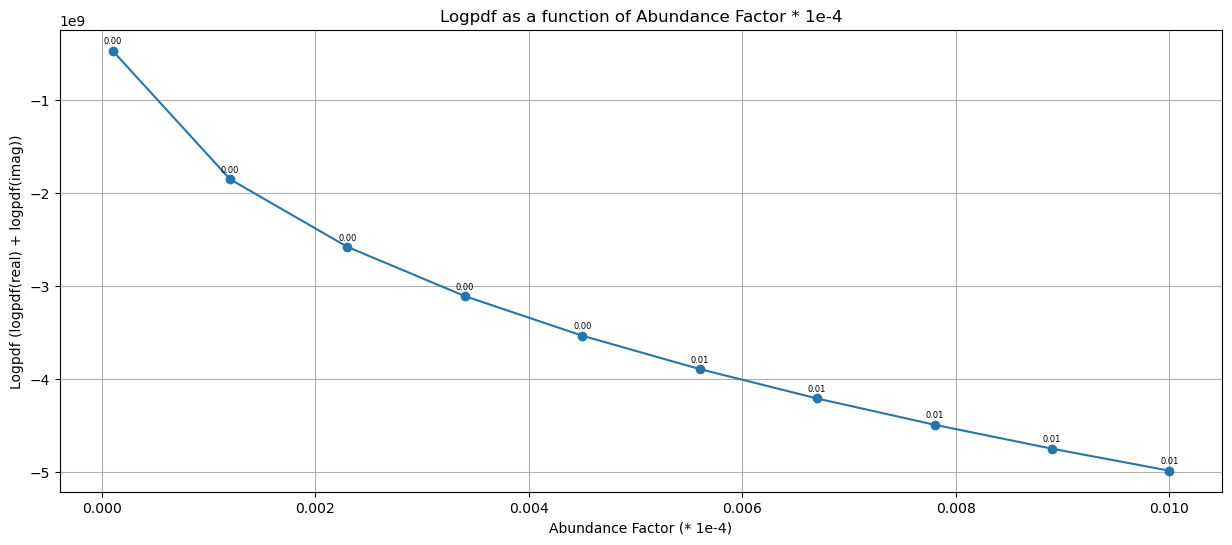

In [185]:
plt.figure(figsize=(15,6))
plt.plot(abundance_factors, logpdf_list, marker='o', linestyle='-')
plt.xlabel('Abundance Factor (* 1e-4)')
plt.ylabel('Logpdf (logpdf(real) + logpdf(imag))')
plt.title('Logpdf as a function of Abundance Factor * 1e-4')
plt.grid(True)

# Annotate each point with its abundance factor value
for x, y in zip(abundance_factors, logpdf_list):
    plt.annotate(f'{x:.2f}', (x, y),
                 textcoords="offset points", xytext=(0,5), ha='center', fontsize=6)

plt.show()

In [181]:
logpdf_list

[Array(-4.9828558e+09, dtype=float64),
 Array(-2.09151556e+10, dtype=float64),
 Array(-2.39432049e+10, dtype=float64),
 Array(-2.57812722e+10, dtype=float64),
 Array(-2.70749153e+10, dtype=float64)]

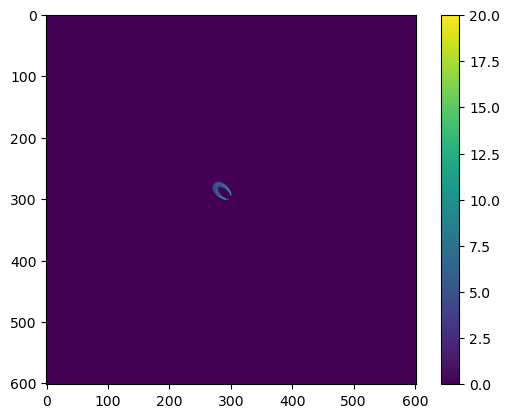

In [186]:
plt.imshow(grid_search_images[0][0][0])
plt.colorbar()

computing pinhole spectral cube for a total of 1 frequencies


(1, 602, 602)

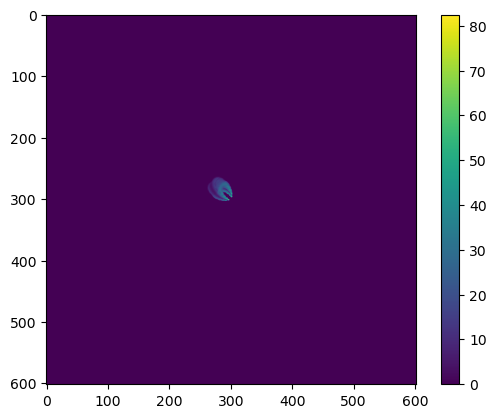

In [173]:
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=10*1e-4, # For every H how much is CO
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs_selected,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
plt.imshow(images[0])
plt.colorbar()
images.shape

## Initialize MCMC

In [23]:
import inference 

from importlib import reload
reload(inference)

################################################################################
# 1) Create the disk_params dictionary (instead of DiskFlaherty object).
################################################################################
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4, # For every H how much is CO
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

disk_params_mcmc = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4, # For every H how much is CO
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

################################################################################
# 2) Build the disk grid (z and r) for computing temperature, densities, etc.
################################################################################
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

################################################################################
# 3) Set up projection and rays
################################################################################
projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs_selected
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / data_cube.nxpix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)
energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

# bounding box for interpolation
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

################################################################################
# 4) Set up the posterior parameters
################################################################################
param_index_dict = inference.DISK_PARAM_INDEX

posterior_params = {
    param_index_dict['q']: {
        'bounds': [-0.5, 0.0],
        'p0_range': [-0.5, 0.0],
    },
    param_index_dict['log_r_c']: {
        'bounds': [1.75, 2.50],
        'p0_range': [1.75, 2.50],
    },
    param_index_dict['v_turb']: {
        'bounds': [0.0, 1.0],
        'p0_range': [0.0, 1.0],
    },
    param_index_dict['T_atm1']: {
        'bounds': [40.0, 150.0],
        'p0_range': [40.0, 150.0],
    },
    param_index_dict['T_mid1']: {
        'bounds': [5.0, 40.0],
        'p0_range': [5.0, 40.0],
    },
    param_index_dict['r_in']: {
        'bounds': [1.0, 20.0],
        'p0_range': [1.0, 20.0],
    },
    param_index_dict['r_break']: {
        'bounds': [15.0, 115.0],
        'p0_range': [15.0, 115.0],
    },
    param_index_dict['q_in']: {
        'bounds': [-1.0, 0.0],
        'p0_range': [-1.0, 0.0],
    }
}

################################################################################
# 5) Create the sampler_dict 
################################################################################
sampler_dict = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=ray_coords_polar,
    obs_dir=obs_dir_pinhole,
    beam=None, # No beam for visibilities MCMC
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=vis_sigma_binned,
    disk_params=disk_params,
    posterior_params=posterior_params,
    nu0=nu0
)

################################################################################
# 6) Initialize the walkers
################################################################################
ndim = len(list(posterior_params.keys()))    
nwalkers = 80
nsteps = 700 # Example number of MCMC steps
num_iter_restart = 80
restart_cluster_size = 1e-2

# Sample initial positions p0 from the param_bounds
p0 = inference.sample_p0(nwalkers, posterior_params, seed=1337)

In [25]:
from importlib import reload
reload(inference)
################################################################################
# 7) Set up and run the emcee MCMC
################################################################################
backend = emcee.backends.HDFBackend("vis_mcmc_run1_20channels.h5")
backend.reset(nwalkers, ndim)

def logprob_wrapper(params):
    """
    A small wrapper that calls the functional logprob with the 
    arguments we need: the data (images_ground_truth_blurred) 
    and frequencies, plus the sampler_dict.
    """
    # params, vis_grid, vis_weight, vis_density_weight, npix, freqs_selected, sampler_dict
    return inference.logprob_uv(params, vis_grid, vis_weight, vis_density_weight, npix, vis_nonzero_indices, freqs_selected, sampler_dict)

sampler = emcee.EnsembleSampler(
    nwalkers=nwalkers,
    ndim=ndim,
    log_prob_fn=logprob_wrapper,
    backend=backend
)

print("Running MCMC...")
warmup_sampler = sampler.run_mcmc(p0, num_iter_restart, progress=True)
flat_samples = sampler.get_chain(flat=True)
warmup_medians = np.median(flat_samples, axis=0)
p1 = np.random.normal(warmup_medians,  restart_cluster_size * np.abs(warmup_medians), size=(nwalkers, ndim))

print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

start_time_mcmc = time.time()
sampler.run_mcmc(p1, nsteps, progress=True)
end_time_mcmc = time.time()
mcmc_time = end_time_mcmc - start_time_mcmc
print(f"MCMC completed in {mcmc_time:.2f} seconds.")
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))

Running MCMC...


100%|████████████████████████████████████████████| 80/80 [1:31:43<00:00, 68.79s/it]


Mean acceptance fraction: 0.29046875


 37%|██████████████▉                         | 261/700 [5:11:37<8:34:39, 70.34s/it]2025-04-09 11:04:14.727127: W external/xla/xla/tsl/framework/bfc_allocator.cc:497] Allocator (GPU_0_bfc) ran out of memory trying to allocate 17.44GiB (rounded to 18726141184)requested by op 
2025-04-09 11:04:14.727819: W external/xla/xla/tsl/framework/bfc_allocator.cc:508] ****_*__**x__*************_*****_****__________******_______________________________________________
E0409 11:04:14.727896  221073 pjrt_stream_executor_client.cc:3084] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 18726141024 bytes.
Traceback (most recent call last):
  File "/u8/d/len/.conda/envs/jax/lib/python3.12/site-packages/emcee/ensemble.py", line 640, in __call__
    return self.f(x, *self.args, **self.kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_221073/1181397608.py", line 16, in logprob_wrapper
    return inference.logprob_uv(params, vis_grid, vis_w

emcee: Exception while calling your likelihood function:
  params: [18.66353351 64.46077835 -0.25737369 -0.56285868 78.41480044 10.82870036
  2.2516447   0.61365643]
  args: []
  kwargs: {}
  exception:


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 18726141024 bytes.

In [8]:
## Restart after OOM
import numpy as np
import time
import emcee
import inference  
# Define the log probability wrapper; adjust this if your function signature changed.
def logprob_wrapper(params):
    return inference.logprob_uv(params, vis_grid, vis_weight, vis_density_weight, npix,
                                vis_nonzero_indices, freqs_selected, sampler_dict)

# Load the backend from the previously saved HDF5 file
backend = emcee.backends.HDFBackend("vis_mcmc_run1_20channels.h5")

# Get the current chain to determine the last state.
# The chain shape is typically (nsteps_completed, nwalkers, ndim)
chain = backend.get_chain(flat=False)
print("Chain shape:", chain.shape)

# Extract the last state for all walkers
last_state = chain[-1]
print("Last state shape:", last_state.shape)

nwalkers, ndim = last_state.shape
p0_new = last_state + 1e-4 * np.random.randn(nwalkers, ndim)

# Reinitialize the sampler. 
sampler = emcee.EnsembleSampler(nwalkers=nwalkers,
                                ndim=ndim,
                                log_prob_fn=logprob_wrapper,
                                backend=backend)

# Resume the MCMC run for nsteps iterations.
print("Resuming MCMC...")
start_time = time.time()
sampler.run_mcmc(p0_new, nsteps, progress=True)
end_time = time.time()
print(f"MCMC resumed and completed in {end_time - start_time:.2f} seconds.")
print("Mean acceptance fraction:", np.mean(sampler.acceptance_fraction))


Chain shape: (341, 80, 8)
Last state shape: (80, 8)
Resuming MCMC...


100%|█████████████████████████████████████████| 700/700 [13:11:35<00:00, 67.85s/it]

MCMC resumed and completed in 47570.15 seconds.
Mean acceptance fraction: 0.07884245917387127


Flat samples shape: (64640, 8)
Chosen parameter values (from MCMC) with their Flaherty's values:
T_mid1: chosen value = 18.8216 (Flaherty's': 17.8000)
T_atm1: chosen value = 63.5251 (Flaherty's': 87.0000)
q: chosen value = -0.2474 (Flaherty's': -0.2700)
q_in: chosen value = -0.5563 (Flaherty's': -0.5700)
r_break: chosen value = 78.5606 (Flaherty's': 70.0000)
r_in: chosen value = 11.1852 (Flaherty's': 11.0000)
log_r_c: chosen value = 2.2229 (Flaherty's': 2.3000)
v_turb: chosen value = 0.6528 (Flaherty's': 0.0600)


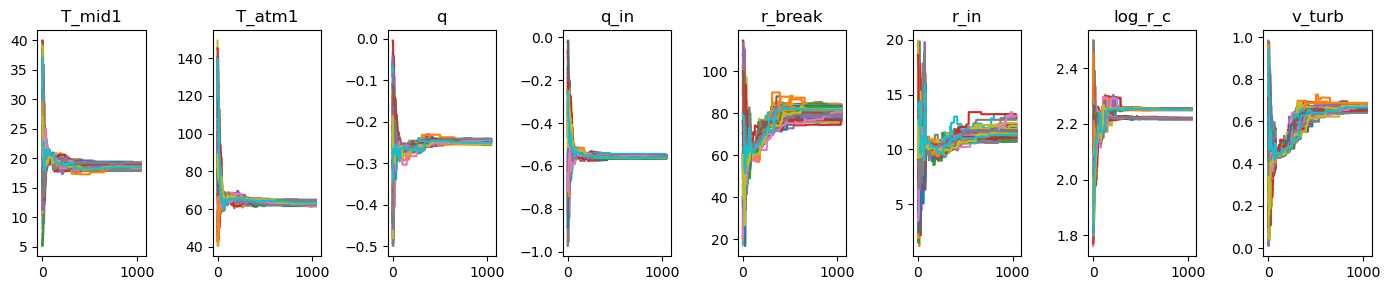

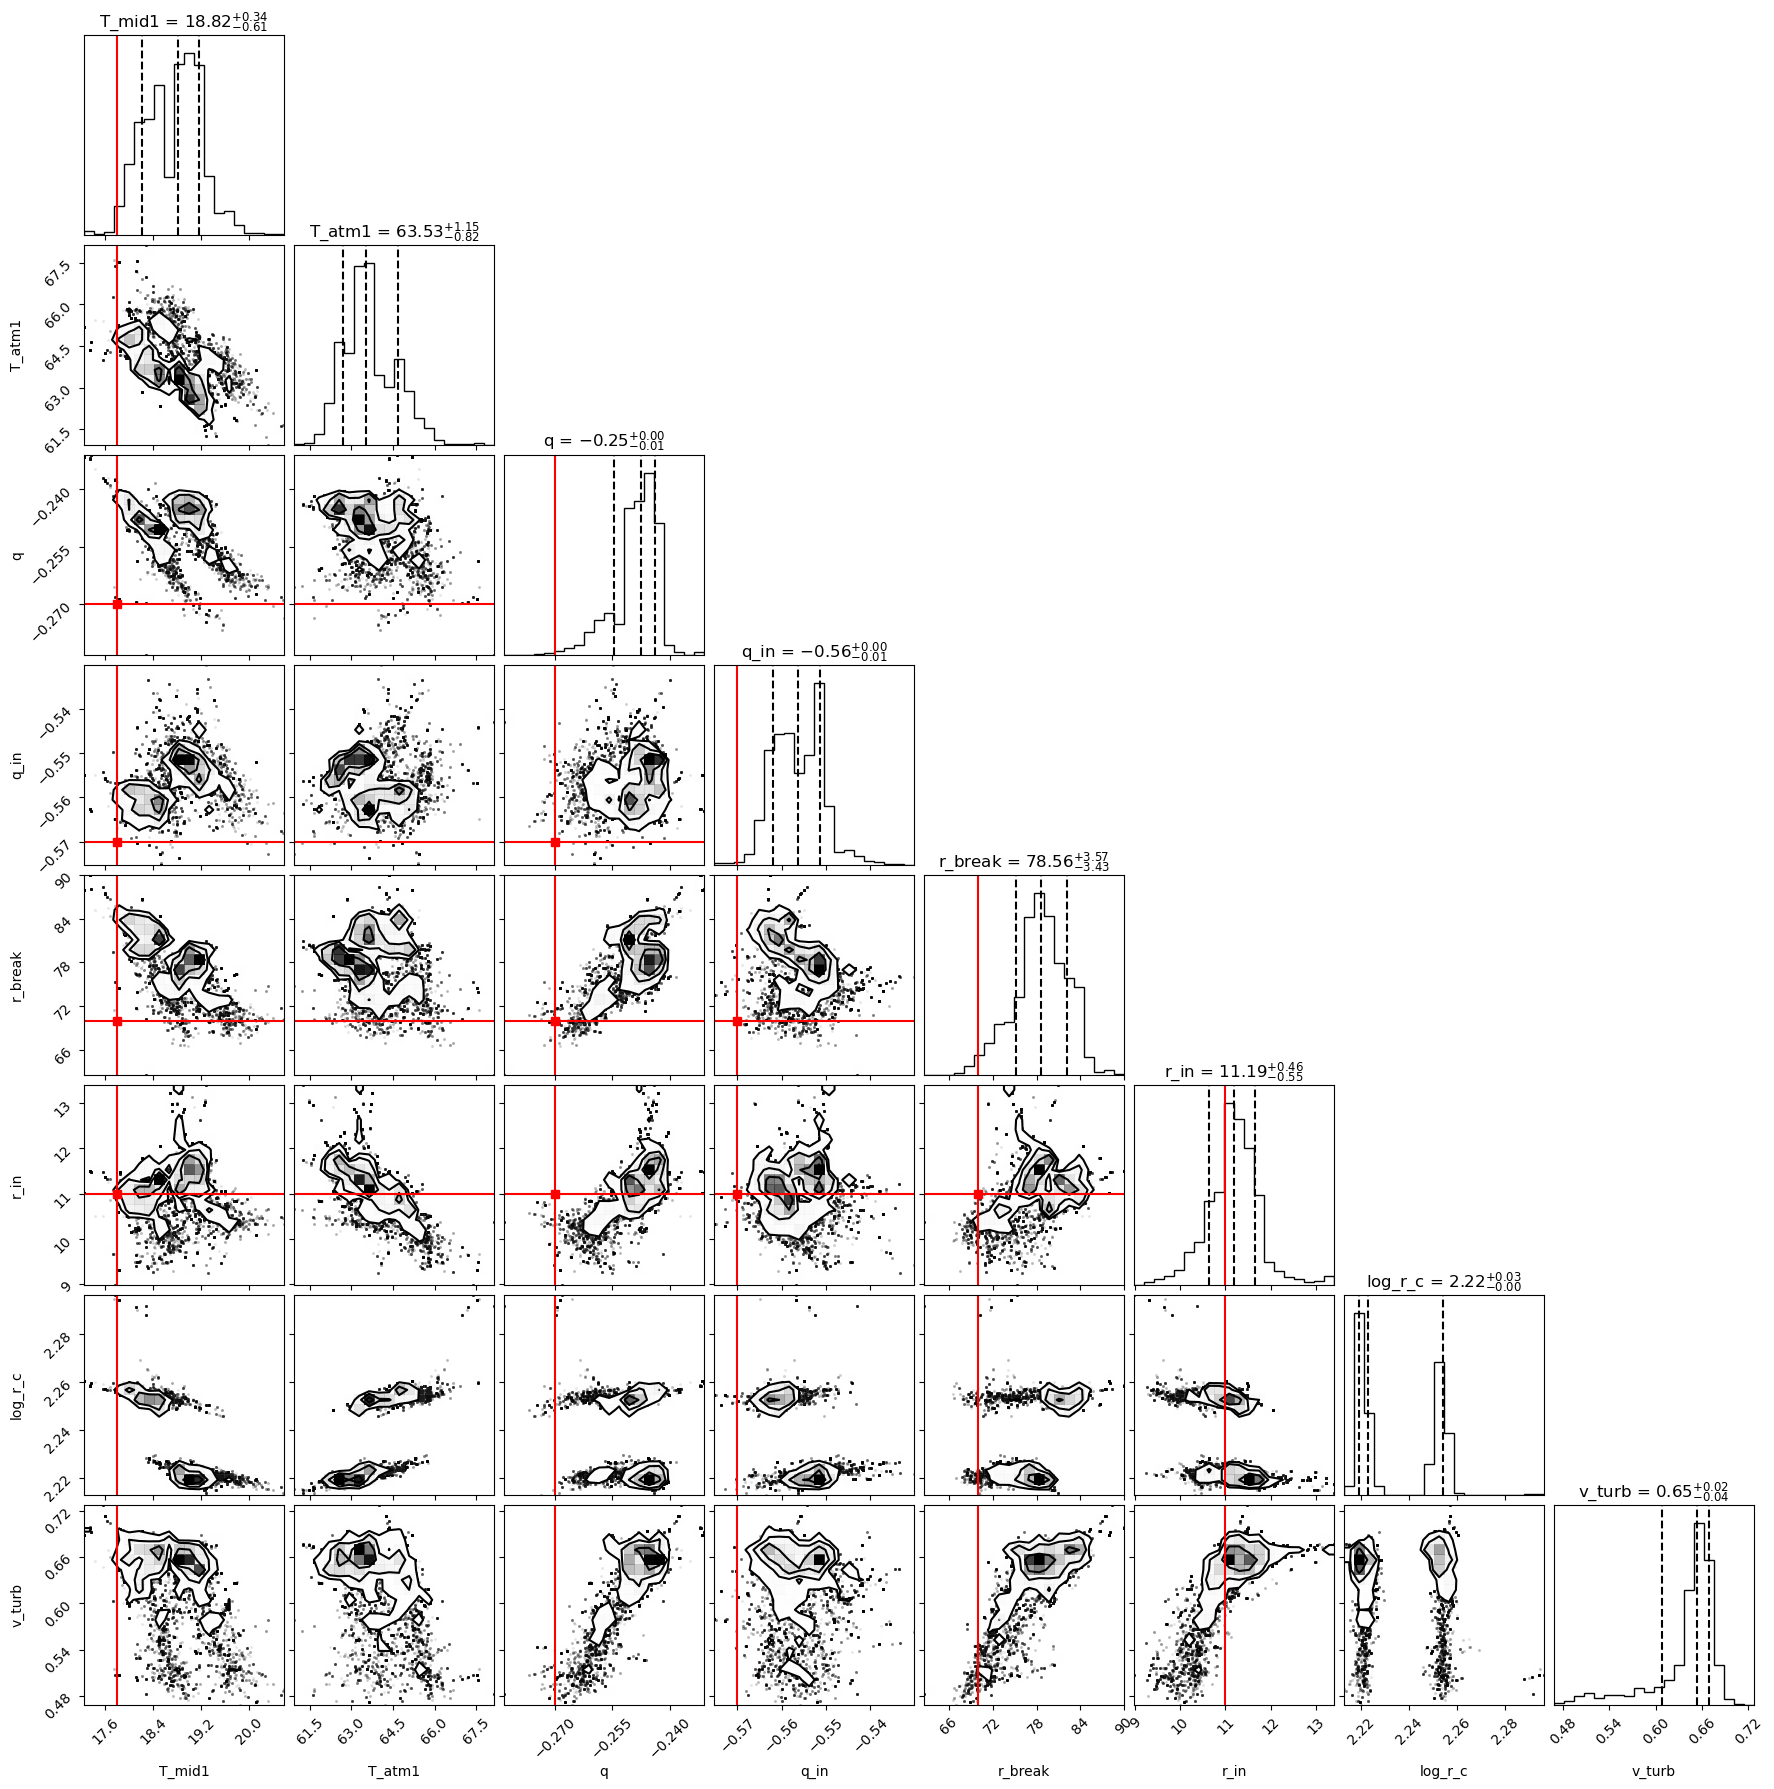

In [27]:
sampler = emcee.backends.HDFBackend("vis_mcmc_run1_20channels.h5")

ground_truth = {
    "q": -0.27,
    "log_r_c": 2.3,
    "v_turb": 0.06,
    "T_atm1": 87.0,
    "T_mid1": 17.8,
    "r_in": 11.0,
    "r_break": 70.0,
    "q_in": -0.57
}

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]

%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
for i in range(ndim):
    axes[i].plot(chain[...,i])
    axes[i].set_title(param_labels[i])

plt.tight_layout()

%matplotlib inline
import corner

flat_samples = sampler.get_chain(discard=nsteps//3, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    inference.REV_DISK_PARAM_INDEX[idx] for idx in sorted(posterior_params.keys())
]


truth_values = [ground_truth[label] for label in param_labels]

# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    truths=truth_values,        # <--- overlay true values
    truth_color="red",          # optional color
    title_kwargs={"fontsize": 12}
)

chosen_values = np.median(flat_samples, axis=0)

print("Chosen parameter values (from MCMC) with their Flaherty's values:")
for label, value in zip(param_labels, chosen_values):
    true_val = ground_truth[label]
    print(f"{label}: chosen value = {value:.4f} (Flaherty's': {true_val:.4f})")

# Load existing MCMC chain and free up CO Abundance as only DOF

In [7]:
from importlib import reload
reload(inference)

old_backend_file = "vis_mcmc_run1_20channels.h5"
backend_old = emcee.backends.HDFBackend(old_backend_file)
flat_chain = backend_old.get_chain(flat=True)
median_free_params = np.median(flat_chain, axis=0)

# The parameters that were free in the old run (in the order sampled):
free_keys = ['T_mid1', 'T_atm1', 'q', 'q_in', 'r_break', 'r_in', 'log_r_c', 'v_turb']

# =============================================================================
# STEP 2: Recreate the full disk parameters dictionary using the chosen values,
#         then update free parameters with medians from the old chain.
# -----------------------------------------------------------------------------
full_disk_params = parametric_disk.create_disk_params(
    T_mid1=17.8,               # chosen value for T_mid1
    T_atm1=87.0,               # chosen value for T_atm1
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    M_star=2.3 * M_sun,
    gamma=1.0,
    r_in=11.0,
    log_r_c=2.3,
    M_gas=0.09 * M_sun,
    v_turb=0.06,
    co_abundance=1e-4,         # fixed in the old run; will be freed in the new run.
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

# Update the free parameters with the medians from the old chain.
for i, key in enumerate(free_keys):
    full_disk_params[key] = median_free_params[i]

print("Recovered full disk parameters:")
for key, value in full_disk_params.items():
    print(f"{key:12s}: {value}")

# =============================================================================
# STEP 3: Set up a new MCMC run where only co_abundance is free.
# -----------------------------------------------------------------------------
free_index = inference.DISK_PARAM_INDEX['co_abundance']
posterior_abundance_params = {
    free_index: {
        'bounds': [0.01 * 1e-4, 2 * 1e-4],
        'p0_range': [0.3 * 1e-4, 1.5 * 1e-4],
    }
}

# =============================================================================
# Set up the grid, projection, and rays.
resolution = 500
z_min, z_max = 0, 200
r_min, r_max = full_disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution),
    jnp.linspace(r_min, r_max, resolution),
    indexing='ij'
)
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs_selected
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / data_cube.nxpix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

ray_coords_sph = grid.cartesian_to_spherical(ray_coords_pinhole)
ray_coords_polar = grid.spherical_to_zr(ray_coords_sph)

energy_levels, radiative_transitions = line_rte.load_molecular_tables(
    path="/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"
)

# =============================================================================
# Compute the Einstein coefficients using the current disk parameters.
# =============================================================================
_, a_ud, b_ud, b_du = line_rte.einstein_coefficients(
    energy_levels, radiative_transitions, transition=full_disk_params['transition']
)

nu0 = 230521497431.8133

# =============================================================================
# Create the new sampler dictionary using the existing create_sampler function.
# =============================================================================
sampler_dict_abundance = inference.create_sampler(
    z_disk=z_disk,
    r_disk=r_disk,
    bbox=bbox_disk,
    pixel_area=pixel_area_pinhole,
    ray_coords=ray_coords_pinhole,
    ray_coords_polar=ray_coords_polar,
    obs_dir=obs_dir_pinhole,
    beam=None, 
    energy_levels=energy_levels,
    radiative_transitions=radiative_transitions,
    sigma=vis_sigma_binned,              
    disk_params=full_disk_params,         
    posterior_params=posterior_abundance_params,
    nu0=nu0  
)

# =============================================================================
# STEP 4: Define a log-probability function for the free parameter (co_abundance).
# =============================================================================
def logprob_abundance(param_free):
    """
    This function updates only 'co_abundance' in the disk parameters,
    builds a new sampler_dict, and calls the visibility-domain log-probability function.
    """
    lower_bound = posterior_abundance_params[free_index]['bounds'][0]
    upper_bound = posterior_abundance_params[free_index]['bounds'][1]
    
    # Check if the proposal is out-of-bounds
    if not (lower_bound <= param_free[0] <= upper_bound):
        return -np.inf
    
    # Update disk parameters with the new free value.
    new_disk_params = full_disk_params.copy()
    new_disk_params['co_abundance'] = param_free[0]
    new_sampler_dict = sampler_dict_abundance.copy()
    new_sampler_dict['disk_params'] = new_disk_params
    
#     print(new_sampler_dict['disk_params'])
    
    # Evaluate log probability using the visibilities function.
    lp = inference.logprob_uv(param_free, vis_grid, vis_weight, vis_density_weight, npix,
                              vis_nonzero_indices, freqs_selected, new_sampler_dict)
    
    # Debug: If lp is NaN, you might want to print or log new_disk_params.
    if np.isnan(lp):
#         print("params:", param_free)
        print("NaN encountered with co_abundance =", param_free[0])
        print("New disk parameters:", new_disk_params)
    return lp

# =============================================================================
# (Optional) Check that the initial log-probability for one p0 value is finite.
# =============================================================================
p0_test = np.random.uniform(low=posterior_abundance_params[free_index]['p0_range'][0],
                              high=posterior_abundance_params[free_index]['p0_range'][1],
                              size=(1,))
test_lp = logprob_abundance(p0_test)
print("Test log probability for initial guess:", test_lp)
if np.isnan(test_lp):
    raise ValueError("Initial log probability is NaN; check your inputs and sigma values.")

# =============================================================================
# STEP 5: Initialize and run the new MCMC sampler for co_abundance.
# =============================================================================
nwalkers = 30         # Number of walkers.
ndim_abundance = 1    # One free parameter.

p0_low, p0_high = posterior_abundance_params[free_index]['p0_range']
p0_abundance = np.random.uniform(low=p0_low, high=p0_high, size=(nwalkers, ndim_abundance))

# Set up a new HDF5 backend for the abundance run.
backend_abundance = emcee.backends.HDFBackend("vis_mcmc_abundance_run.h5")
backend_abundance.reset(nwalkers, ndim_abundance)

sampler_abundance = emcee.EnsembleSampler(nwalkers, ndim_abundance, logprob_abundance,
                                          backend=backend_abundance)

print("Running new MCMC for co_abundance...")

nsteps = 200   # Number of MCMC steps.
sampler_abundance.run_mcmc(p0_abundance, nsteps, progress=True)

flat_chain_abundance = sampler_abundance.get_chain(flat=True)
median_co_abundance = np.median(flat_chain_abundance, axis=0)[0]

print("Median co_abundance from new MCMC run:", median_co_abundance)
print("Mean acceptance fraction:", np.mean(sampler_abundance.acceptance_fraction))

Recovered full disk parameters:
T_mid1      : 18.914008756097953
T_atm1      : 63.70557606940555
q           : -0.2492327819530438
q_in        : -0.5548728889907575
r_break     : 77.57742529588538
M_star      : 4.573319999999999e+33
gamma       : 1.0
r_in        : 11.100846407473194
log_r_c     : 2.2219042240845917
M_gas       : 1.7895599999999997e+32
v_turb      : 0.6465638197095633
co_abundance: 0.0001
N_dissoc    : 1.2561000000000001e+21
N_desorp    : -inf
z_q0        : 70.0
transition  : 2
m_mol       : 3.995774496e-24
freezeout   : 19.0
delta       : 1
r_scale     : 150.0
Test log probability for initial guess: -501600415680.83997
Running new MCMC for co_abundance...


100%|████████████████████████████| 200/200 [1:11:43<00:00, 21.52s/it]

Median co_abundance from new MCMC run: 1.001599379721984e-06
Mean acceptance fraction: 0.32316666666666666


Flat samples shape: (4020, 1)
Chosen parameter values (from MCMC) with their Flaherty's values:
co_abundance: chosen value = 0.0000


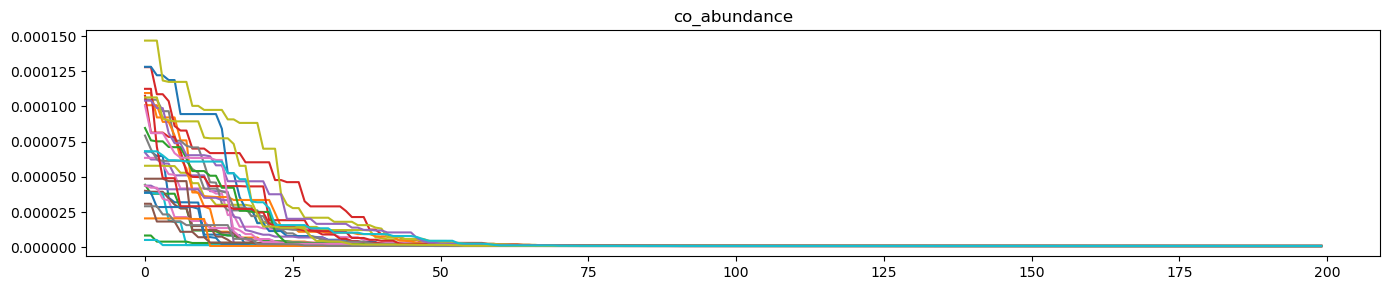

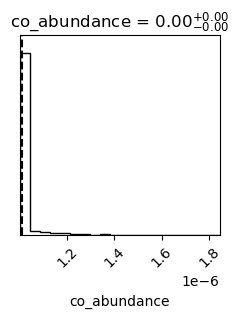

In [8]:
sampler = emcee.backends.HDFBackend("vis_mcmc_abundance_run.h5")

chain = sampler.get_chain()

ndim = chain.shape[-1]
param_labels = [
    'co_abundance'
]
%matplotlib inline
fig, axes = plt.subplots(1, ndim, figsize=(14,3))
axes.plot(chain[...,0])
axes.set_title(param_labels[0])

plt.tight_layout()

%matplotlib inline
import corner

flat_samples = sampler.get_chain(discard=nsteps//3, thin=1, flat=True)
print("Flat samples shape:", flat_samples.shape)  # should be ((nsteps-100)*nwalkers, ndim)

param_labels = [
    'co_abundance'
]


# corner plot
fig = corner.corner(
    flat_samples,
    labels=param_labels,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 12}
)

chosen_values = np.median(flat_samples, axis=0)

print("Chosen parameter values (from MCMC) with their Flaherty's values:")
for label, value in zip(param_labels, chosen_values):
    print(f"{label}: chosen value = {value:.4f}")

# Comparison with Flaherty model in Image domain

In [7]:
fov_as = 10.0                 # arcsecs
velocity_range = (2000, 10000) # m/s

data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
vlsr = 5760   # m/s
isotop_abundance = 1

# data_path = '../data/alma_highres/HD163296_13CO_beam0.20_100ms_3sigma.clean.image.cutout.fits'
# vlsr = 5770   # m/s
# isotop_abundance = 1/69
# 
# data_path = '../data/alma_highres/HD163296_C18O_beam0.20_100ms_3sigma.clean.image.cutout.fits'
# vlsr = 5750   # m/s
# isotop_abundance = 1/557

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)
freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0
npix = data_cube.nxpix

In [18]:
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

    
disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=18.914008756097953,
    T_atm1=63.70557606940555,
    q=-0.2492327819530438,
    q_in=-0.5548728889907575,
    r_break=77.57742529588538,
    r_in=11.100846407473194,
    log_r_c=2.2219042240845917,
    v_turb=0.6465638197095633,
    gamma=1.0,
    M_star=2.3 * M_sun,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)

nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_mcmc,
    disk_params_mcmc['gamma'],
    disk_params_mcmc['r_in'],
    10 ** disk_params_mcmc['log_r_c'],
    disk_params_mcmc['M_gas'],
    disk_params_mcmc['M_star'],
    disk_params_mcmc['m_mol']
)

velocity_az_mcmc = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2_mcmc, 
    temperature_mcmc, 
    disk_params_mcmc
)

################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])

fov_as = 10.0  # arcsecs
# data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
velocity_range = (2000, 10000) # m/s
vlsr = 5770 # systematic velocity of target

data_cube = imagecube(data_path, FOV=fov_as, velocity_range=velocity_range)

# num_freqs_resample = 20
# num_freqs = len(data_cube.freqax)
# idx = np.round(np.linspace(0, num_freqs - 1, num_freqs_resample)).astype(int)

# data = data_cube.data[idx]
# freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)[idx]
# velocities = data_cube.velax[idx]

freqs = data_cube.velocity_to_restframe_frequency(vlsr=vlsr)
velocities = data_cube.velax
data = data_cube.data

x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
nu0 = data_cube.nu0  # e.g. 230.538 GHz
npix = data_cube.nxpix
width_kms = (velocities[-1] - velocities[0]) / 1000.0
delta_v_ms = velocities[1] - velocities[0]
# if num_freqs_resample > 1:
#     delta_v_ms = velocities[1] - velocities[0]
# else: 
#     delta_v_ms = np.inf
print(f'velocity resolution: {delta_v_ms} m/s')

# Shift frequencies so that center is ~nu0
# freqs += nu0 - freqs.mean()

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

images = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az, 
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
images_flaherty_blurred = sensor.fftconvolve_vmap(images, beam)

images_mcmc = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_mcmc,
    nd_co_mcmc,
    temperature_mcmc,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)
images_mcmc_blurred = sensor.fftconvolve_vmap(images_mcmc, beam)

velocity resolution: 199.99999998061412 m/s
computing pinhole spectral cube for a total of 40 frequencies
computing pinhole spectral cube for a total of 40 frequencies


In [9]:

disk_params_alt = parametric_disk.create_disk_params(
    q        = -0.193,                
    q_in     = -0.403,                
    r_break  = 105.337,                
    log_r_c  = 2.216,                 
    v_turb   = 0.390,                  
    T_mid1   = 17.938,               
    T_atm1   = 62.838,                 
    gamma    = 1.0,
    M_star   = 2.3 * M_sun,
    r_in     = 19.861,                 
    M_gas    = 0.09 * M_sun,
    co_abundance = 1e-4,
    N_dissoc     = 0.79 * 1.59e21,
    N_desorp     = -np.inf,
    freezeout    = 19.0,
    r_scale      = 150.0,
    z_q0         = 70.0,
    delta        = 1,
    transition   = 2,
    m_mol        = 2.37 * m_h,
)

temperature_alt = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_alt)

nd_h2_alt = parametric_disk.number_density_profile(
    z_disk, r_disk, temperature_alt,
    disk_params_alt['gamma'],
    disk_params_alt['r_in'],
    10**disk_params_alt['log_r_c'],
    disk_params_alt['M_gas'],
    disk_params_alt['M_star'],
    disk_params_alt['m_mol']
)

velocity_az_alt = parametric_disk.velocity_profile(
    z_disk, r_disk, nd_h2_alt, temperature_alt, disk_params_alt
)

N_h2_alt = parametric_disk.surface_density(z_disk, nd_h2_alt)
abundance_co_alt = parametric_disk.co_abundance_profile(N_h2_alt, temperature_alt, disk_params_alt)
nd_co_alt = abundance_co_alt * nd_h2_alt

images_mcmc_img = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_alt,
    nd_co_alt,
    temperature_alt,
    -velocity_az_alt,    # note the same sign convention
    bbox_disk,
    freqs=freqs,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_img_blurred = sensor.fftconvolve_vmap(images_mcmc_img, beam)

computing pinhole spectral cube for a total of 40 frequencies


In [14]:
def plot_data_cube_comparison(data_cube, images_flaherty, images_mcmc, images_mcmc_vis, channel):
    """
    Plots a comparison for a given channel from four image cubes:
      - Row 0: Data, Flaherty image, |Data–Flaherty| residual (with mean abs in title)
      - Row 1: Data, Image‐Domain MCMC image, |Data–MCMC| residual
      - Row 2: Data, Spectral‐Domain MCMC image, |Data–MCMC+vis| residual
    All panels are square, have no axis ticks/labels, and both data/model/residual
    panels share the same color scale.
    """
    data_slice = data_cube[channel]
    freq_ghz   = freqs[channel] * 1e-9

    rows = [
        ("Flaherty",             images_flaherty[channel]),
        ("Image-Domain MCMC",    images_mcmc[channel]),
        ("Spectral-Domain MCMC", images_mcmc_vis[channel]),
    ]

    fig, ax = plt.subplots(3, 3, figsize=(12, 12))

    # Determine a common color scale across all panels in all rows
    # (for absolute residual, it will be clipped/saturated, but matches the others)
    common_vmin = data_slice.min()
    common_vmax = data_slice.max()

    for i, (label, model_sl) in enumerate(rows):
        # Column 0: Data
        im0 = ax[i, 0].imshow(
            data_slice,
            origin="lower",
            cmap="inferno",
            vmin=common_vmin,
            vmax=common_vmax,
            aspect="equal",
        )
        ax[i, 0].set_title(f"Data\n({freq_ghz:.4f} GHz)")
        ax[i, 0].set_xticks([])
        ax[i, 0].set_yticks([])
        plt.colorbar(im0, ax=ax[i, 0], fraction=0.046, pad=0.04)

        # Column 1: Model
        im1 = ax[i, 1].imshow(
            model_sl,
            origin="lower",
            cmap="inferno",
            vmin=common_vmin,
            vmax=common_vmax,
            aspect="equal",
        )
        ax[i, 1].set_title(label)
        ax[i, 1].set_xticks([])
        ax[i, 1].set_yticks([])
        plt.colorbar(im1, ax=ax[i, 1], fraction=0.046, pad=0.04)

        # Column 2: Absolute residual, but using same vmin/vmax
        abs_res = np.abs(data_slice - model_sl)
        mean_abs = abs_res.mean()
        im2 = ax[i, 2].imshow(
            abs_res,
            origin="lower",
            cmap="inferno",
            vmin=common_vmin,
            vmax=common_vmax,
            aspect="equal",
        )
        ax[i, 2].set_title(f"|Data – {label}|\nmean={mean_abs:.2e}")
        ax[i, 2].set_xticks([])
        ax[i, 2].set_yticks([])
        plt.colorbar(im2, ax=ax[i, 2], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()


In [ ]:
channel = 8
plot_data_cube_comparison(data, images_flaherty_blurred, images_mcmc_img_blurred, images_mcmc_blurred, channel)

In [20]:
residual_flaherty = images_flaherty_blurred - data
chi2_flaherty = np.sum(((residual_flaherty) / 0.0073)**2)
reduced_chi2_flaherty = chi2_flaherty / images_flaherty_blurred.size
residual_sum_flaherty = np.sum(np.abs(residual_flaherty))
residual_mean_flaherty = np.mean(np.abs(residual_flaherty))

residual_mcmc = images_mcmc_blurred - data
chi2_mcmc = np.sum(((residual_mcmc) / 0.0073)**2)
reduced_chi2_mcmc = chi2_mcmc / images_mcmc_blurred.size
residual_sum_mcmc = np.sum(np.abs(residual_mcmc))
residual_mean_mcmc = np.mean(np.abs(residual_mcmc))

residual_mcmc_image = images_mcmc_img_blurred - data
chi2_mcmc_image = np.sum(((residual_mcmc_image) / 0.0073)**2)
reduced_chi2_mcmc_image = chi2_mcmc_image / images_mcmc_img_blurred.size
residual_sum_mcmc_image = np.sum(np.abs(residual_mcmc_image))
residual_mean_mcmc_image = np.mean(np.abs(residual_mcmc_image))

l2_loss_flaherty = np.sum(np.square(residual_flaherty))
l2_loss_mcmc = np.sum(np.square(residual_mcmc))
rms_flaherty = np.sqrt(np.mean(np.square(residual_flaherty)))
rms_mcmc = np.sqrt(np.mean(np.square(residual_mcmc)))

mae_flaherty = np.mean(np.abs(residual_flaherty))
mae_mcmc_vis = np.mean(np.abs(residual_mcmc))
mae_mcmc_img = np.mean(np.abs(residual_mcmc_image))

print("Flaherty L2 (sum of squares):", l2_loss_flaherty)
print("MCMC L2 (sum of squares):", l2_loss_mcmc)
print("Flaherty RMS:", rms_flaherty)
print("MCMC RMS:", rms_mcmc)

print(f"Flaherty Reduced Chi-squared: {chi2_flaherty/images_mcmc_img_blurred.size}, Spectral Domain Reduced Chi-squared: {chi2_mcmc/images_mcmc_img_blurred.size}, Image Domain Reduced Chi-squared: {chi2_mcmc_image/images_mcmc_img_blurred.size}")
print(f"Flaherty MAE: {mae_flaherty:.4f} Jy/beam, Spectral Domain MAE: {mae_mcmc_vis:.4f} Jy/beam, Image Domain MAE: {mae_mcmc_img:.4f} Jy/beam")

Flaherty L2 (sum of squares): 304.80966391412636
MCMC L2 (sum of squares): 148.9256922022005
Flaherty RMS: 0.005498961173018951
MCMC RMS: 0.003843714312517848
Flaherty Reduced Chi-squared: 0.5674343025402504, Spectral Domain Reduced Chi-squared: 0.2772403774864806, Image Domain Reduced Chi-squared: 0.23921535289946066
Flaherty MAE: 0.0026 Jy/beam, Spectral Domain MAE: 0.0022 Jy/beam, Image Domain MAE: 0.0021 Jy/beam


In [31]:
# Define the parameter values as dictionaries or lists.
parameters = [
    ("T_mid1", 18.914008756097953, 17.8000),
    ("T_atm1", 63.70557606940555, 87.0000),
    ("q", -0.2492327819530438, -0.2700),
    ("q_in", -0.5548728889907575, -0.5700),
    ("r_break", 77.57742529588538, 70.0000),
    ("r_in", 11.100846407473194, 11.0000),
    ("log_r_c", 2.2219042240845917, 2.3000),
    ("v_turb", 0.6465638197095633, 0.0600)
]

# Print table header
print(f"{'Parameter':<10} {'MCMC on Vis':>10} {'Flaherty':>10} {'Difference':>12}")
print("-" * 46)

# Compute and print each row: difference = chosen - Flaherty
for name, chosen, flaherty in parameters:
    difference = chosen - flaherty
    print(f"{name:<10} {chosen:10.4f} {flaherty:10.4f} {difference:12.4f}")


Parameter  MCMC on Vis   Flaherty   Difference
----------------------------------------------
T_mid1        18.9140    17.8000       1.1140
T_atm1        63.7056    87.0000     -23.2944
q             -0.2492    -0.2700       0.0208
q_in          -0.5549    -0.5700       0.0151
r_break       77.5774    70.0000       7.5774
r_in          11.1008    11.0000       0.1008
log_r_c        2.2219     2.3000      -0.0781
v_turb         0.6466     0.0600       0.5866


# Comparison with Flaherty model in Visibility domain

In [13]:
disk_params = parametric_disk.create_disk_params(
    q=-0.27,
    q_in=-0.57,
    r_break=70,
    log_r_c=2.3,
    v_turb=0.06,
    T_atm1=87.0,
    gamma=1.0,
    T_mid1=17.8,
    M_star=2.3 * M_sun,
    r_in=11.0,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

# T_mid1: chosen value = 18.8216 (Flaherty's': 17.8000)
# T_atm1: chosen value = 63.5251 (Flaherty's': 87.0000)
# q: chosen value = -0.2474 (Flaherty's': -0.2700)
# q_in: chosen value = -0.5563 (Flaherty's': -0.5700)
# r_break: chosen value = 78.5606 (Flaherty's': 70.0000)
# r_in: chosen value = 11.1852 (Flaherty's': 11.0000)
# log_r_c: chosen value = 2.2229 (Flaherty's': 2.3000)
# v_turb: chosen value = 0.6528 (Flaherty's': 0.0600)

disk_params_mcmc = parametric_disk.create_disk_params(
    T_mid1=18.8216,
    T_atm1=63.5251,
    q=-0.2474,
    q_in=-0.5563,
    r_break=78.5606,
    r_in=11.1852,
    log_r_c=2.2229,
    v_turb=0.6528,
    gamma=1.0,
    M_star=2.3 * M_sun,
    M_gas=0.09 * M_sun,
    co_abundance=1e-4,
    N_dissoc=0.79 * 1.59e21,
    N_desorp=-np.inf,
    freezeout=19.0,
    r_scale=150.0,
    z_q0=70.0,
    delta=1,
    transition=2,
    m_mol=2.37 * m_h,
)

resolution = 500
z_min, z_max = 0, 200
r_min, r_max = disk_params['r_in'], 800
z_disk, r_disk = jnp.meshgrid(
    jnp.linspace(z_min, z_max, resolution), 
    jnp.linspace(r_min, r_max, resolution), 
    indexing='ij'
)
molecular_table = "/nfs/rhea.dgp/u8/d/len/code/radjax_updated/molecular_tables/molecule_12c16o.inp"

################################################################################
# 3) Use the functional approach to compute temperature, number density, velocity
################################################################################
temperature = parametric_disk.temperature_profile(z_disk, r_disk, disk_params)

nd_h2 = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature,
    disk_params['gamma'],
    disk_params['r_in'],
    10 ** disk_params['log_r_c'],
    disk_params['M_gas'],
    disk_params['M_star'],
    disk_params['m_mol']
)

velocity_az = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2, 
    temperature, 
    disk_params
)

temperature_mcmc = parametric_disk.temperature_profile(z_disk, r_disk, disk_params_mcmc)

nd_h2_mcmc = parametric_disk.number_density_profile(
    z_disk, 
    r_disk, 
    temperature_mcmc,
    disk_params_mcmc['gamma'],
    disk_params_mcmc['r_in'],
    10 ** disk_params_mcmc['log_r_c'],
    disk_params_mcmc['M_gas'],
    disk_params_mcmc['M_star'],
    disk_params_mcmc['m_mol']
)

velocity_az_mcmc = parametric_disk.velocity_profile(
    z_disk, 
    r_disk, 
    nd_h2_mcmc, 
    temperature_mcmc, 
    disk_params_mcmc
)

################################################################################
# 4) Compute column density, CO abundance, etc. (still purely functional)
################################################################################
N_h2 = parametric_disk.surface_density(z_disk, nd_h2)
N_h2_mcmc = parametric_disk.surface_density(z_disk, nd_h2_mcmc)

abundance_co = parametric_disk.co_abundance_profile(N_h2, temperature, disk_params)
nd_co = abundance_co * nd_h2

abundance_co_mcmc = parametric_disk.co_abundance_profile(N_h2_mcmc, temperature_mcmc, disk_params_mcmc)
nd_co_mcmc = abundance_co_mcmc * nd_h2_mcmc

################################################################################
# 5) Prepare bounding box for interpolation
################################################################################
bbox_disk = jnp.array([(au*z_min, au*z_max), (au*r_min, au*r_max)])


# data_path = '~/code/radjax/data/alma/HD163296_CO_highres_cen.cm.fits'
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'

fov_as = 12.0
data_path = '/scratch/ondemand28/len/data/radjax/MAPS/HD_163296_CO_220GHz.0.2arcsec.image.fits'
data_cube = imagecube(data_path, FOV=fov_as)
x_sky, y_sky = np.meshgrid(data_cube.xaxis, data_cube.yaxis, indexing='xy')
npix = data_cube.nxpix
beams_per_pix = data_cube.beams_per_pix

nu0 = 230521497431.8133 # From MS['REF_FREQUENCY']

projection_pinhole = sensor.PinholeProjection(
    name='HD163296',
    x_sky=x_sky,
    y_sky=y_sky,
    distance=122.0,
    nray=100,
    incl=47.5,
    phi=0.0,
    posang=312.0,
    z_width=2 * z_max,
    freqs=freqs
)

fov_rad = fov_as * arcsec
fov = 2 * projection_pinhole.distance * pc * np.tan(fov_rad / 2.0)
pixel_area_pinhole = (fov / npix) ** 2

ray_coords_pinhole, obs_dir_pinhole = sensor.pinhole_disk_projection(
    projection_pinhole.x_sky,
    projection_pinhole.y_sky,
    projection_pinhole.distance,
    projection_pinhole.nray,
    projection_pinhole.incl,
    projection_pinhole.phi,
    projection_pinhole.posang,
    projection_pinhole.z_width
)

beam = data_cube.beams_per_pix * sensor.beam(
    data_cube.dpix, data_cube.bmaj, data_cube.bmin, data_cube.bpa
)

images_flaherty_vis_freqs = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params,
    nd_co,
    temperature,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs_selected,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

images_mcmc_flaherty_vis_freqs = render_cube_pinhole(
    ray_coords_pinhole,
    pixel_area_pinhole,
    disk_params_mcmc,
    nd_co_mcmc,
    temperature_mcmc,
    -velocity_az,  # note sign convention
    bbox_disk,
    freqs=freqs_selected,
    nu0=nu0,
    obs_dir=obs_dir_pinhole,
    molecular_table=molecular_table
)

computing pinhole spectral cube for a total of 20 frequencies
computing pinhole spectral cube for a total of 20 frequencies


In [14]:

from importlib import reload
reload(vis_utils)

flaherty_cube_padded = pad_image_cube(images_flaherty_vis_freqs, vis_npix) 
gridded_flaherty_vis = vis_utils.image_to_gridded_visibility_cube(flaherty_cube_padded, vis_weight, vis_density_weight, vis_npix, True)

mcmc_cube_padded = pad_image_cube(images_mcmc_flaherty_vis_freqs, vis_npix) 
gridded_mcmc_vis = vis_utils.image_to_gridded_visibility_cube(mcmc_cube_padded, vis_weight, vis_density_weight, vis_npix, True)

In [ ]:
import jax.scipy as jsp

vis_grid_loose_pixels = vis_grid[vis_nonzero_indices]
flaherty_loose_pixels = gridded_flaherty_vis[vis_nonzero_indices]
sigma_loose_pixels = vis_sigma_binned[vis_nonzero_indices]

logpdf_re = jsp.stats.norm.logpdf(jnp.real(vis_grid_loose_pixels), jnp.real(flaherty_loose_pixels), sigma_loose_pixels)
logpdf_im = jsp.stats.norm.logpdf(jnp.imag(vis_grid_loose_pixels), jnp.imag(flaherty_loose_pixels), sigma_loose_pixels)

np.sum(logpdf_re) + np.sum(logpdf_im) # -8.27580782e+11 for 1e-4

In [199]:
vis_grid_loose_pixels = vis_grid[vis_nonzero_indices]
flaherty_loose_pixels = gridded_flaherty_vis[vis_nonzero_indices]
mcmc_loose_pixels = gridded_mcmc_vis[vis_nonzero_indices]
sigma_loose_pixels = vis_sigma_binned[vis_nonzero_indices]

In [200]:
residual_flaherty_vis = gridded_flaherty_vis - vis_grid
residual_flaherty_loose_vis = flaherty_loose_pixels - vis_grid_loose_pixels
chi2_flaherty_vis = np.sum(np.abs(residual_flaherty_loose_vis)**2 / sigma_loose_pixels**2)
reduced_chi2_flaherty_vis = chi2_flaherty_vis / vis_grid_loose_pixels.size
residual_sum_flaherty_vis = np.sum(np.abs(residual_flaherty_vis))
residual_mean_flaherty_vis = np.mean(np.abs(residual_flaherty_vis))
residual_sum_flaherty_loose_vis = np.sum(np.abs(residual_flaherty_loose_vis))
residual_mean_flaherty_loose_vis = np.mean(np.abs(residual_flaherty_loose_vis))

residual_mcmc_vis = gridded_mcmc_vis - vis_grid
residual_mcmc_loose_vis = mcmc_loose_pixels - vis_grid_loose_pixels
chi2_mcmc_vis = np.sum(np.abs(residual_mcmc_loose_vis)**2 / sigma_loose_pixels**2)
reduced_chi2_mcmc_vis = chi2_mcmc_vis / vis_grid_loose_pixels.size
residual_sum_mcmc_vis = np.sum(np.abs(residual_mcmc_vis))
residual_mean_mcmc_vis = np.mean(np.abs(residual_mcmc_vis))
residual_sum_mcmc_loose_vis = np.sum(np.abs(residual_mcmc_loose_vis))
residual_mean_mcmc_loose_vis = np.mean(np.abs(residual_mcmc_loose_vis))

In [201]:
header = "{:<30s} {:>20s} {:>20s}".format("Metric (loose visibilities)", "Flaherty", "MCMC")
separator = "-" * len(header)

# Format the rows.
row_reduced_chi2 = "{:<30s} {:>20.2f} {:>20.2f}".format(
    "Reduced Chi²", reduced_chi2_flaherty_vis, reduced_chi2_mcmc_vis
)
row_mean_residual = "{:<30s} {:>20.4e} {:>20.4e}".format(
    "Mean Absolute Residual", residual_mean_flaherty_loose_vis, residual_mean_mcmc_loose_vis
)

# Print the report table
print(header)
print(separator)
print(row_reduced_chi2)
print(row_mean_residual)

Metric (loose visibilities)                Flaherty                 MCMC
------------------------------------------------------------------------
Reduced Chi²                              710662.03            419923.33
Mean Absolute Residual                   3.9461e+01           2.8275e+01


In [197]:
reduced_chi2_mcmc_vis

np.float64(419923.32802803663)

In [ ]:
np.sum(np.abs(model - data)**2 / sigma**2) / model.size